In [17]:
import pandas as pd
import numpy as np
import cv2
import os
from pathlib import Path
import matplotlib.pyplot as plt
import string
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Reshape, Dense, Input, BatchNormalization, Activation, Bidirectional, GRU, LeakyReLU, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.backend import ctc_batch_cost
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

mother_path = Path().resolve().parent
data_path = mother_path.joinpath('data')
arg_data = data_path.joinpath('arg_plate_dataset')
arg_train_datapath = arg_data.joinpath('train')
arg_val_datapath = arg_data.joinpath('valid')

img_test_path = arg_train_datapath.joinpath("2020-16-07_1227-02_95_510.png")

In [3]:
# Read img path and label
df_train = pd.read_csv(arg_data/'train_anotaciones.csv')
df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=42)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = pd.read_csv(arg_data/'valid_anotaciones.csv')

#### Set up image/label pair

In [4]:
def img_label(df):
    """
    Extract image path and label pair
    """
    image_paths = [os.path.join(arg_data, img) for img in df['image_path'].tolist()]
    labels = df['plate_text'].tolist()

    return image_paths, labels

In [5]:
train_img, train_labels = img_label(df_train)
val_img, val_labels = img_label(df_val)
test_img, test_labels = img_label(df_test)

#### Preprocessing Images

In [6]:
# Define image size
IMG_WIDTH = 128
IMG_HEIGHT = 32

# Character set (digits + uppercase letters)
characters = string.digits + string.ascii_uppercase 
char_to_index = {char: idx for idx, char in enumerate(characters)}
index_to_char = {idx: char for char, idx in char_to_index.items()}

# Define image size
IMG_WIDTH, IMG_HEIGHT = 128, 32

def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        print(f"Error: Could not load image {image_path}")
        return None
    
    # Apply CLAHE (Adaptive Contrast Enhancement)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    
    # Resize the image
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
    
    # Apply Gamma Correction (Brightness Adjustment)
    gamma = 1.5  # Higher values = brighter image
    img = np.power(img / 255.0, gamma) * 255.0  # Normalize, adjust, and scale back
    
    # Normalize and expand dimensions
    img = img.astype('float32') / 255.0  # Normalize to [0,1]
    img = np.expand_dims(img, axis=-1)  # Add channel = 1
    
    return img


# Function to encode text labels into numbers
def encode_label(label):
    return np.array([char_to_index[char] for char in label])

# Process dataset images and labels
def process_dataset(image_paths, labels):
    X = []
    Y = []
    for i, img_path in enumerate(image_paths):
        img = preprocess_image(img_path)
        if img is not None:
            X.append(img)
            Y.append(encode_label(labels[i]))

    # Convert lists to NumPy arrays
    X = np.array(X)
    Y = np.array(Y, dtype=object)  # Keep as object dtype since label lengths vary
    return X, Y

In [7]:
# Process training, validation, and test sets
X_train, Y_train = process_dataset(train_img, train_labels)
X_val, Y_val = process_dataset(val_img, val_labels)
X_test, Y_test = process_dataset(test_img, test_labels)

print("Training Data Shape:", X_train.shape)
print("Validation Data Shape:", X_val.shape)
print("Test Data Shape:", X_test.shape)

Training Data Shape: (2818, 32, 128, 1)
Validation Data Shape: (705, 32, 128, 1)
Test Data Shape: (763, 32, 128, 1)


In [8]:
NUM_CLASSES = len(characters)+1

# CNN Feature Extractor
def build_ctc_model():
    input_layer = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1), name='image_input')
    
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)

    # Reshape for CTC (Convert to time-distributed format)
    x = Reshape((-1, 128))(x)

    # Fully connected layer
    x = Dense(64, activation='relu')(x)
    x = Dense(NUM_CLASSES, activation='softmax')(x)

    # Labels and CTC loss input
    labels = Input(shape=(None,), dtype="int32", name="label_input")  # Variable length
    input_length = Input(shape=(1,), dtype="int32", name="input_length")  # Image sequence length
    label_length = Input(shape=(1,), dtype="int32", name="label_length")  # True label length

    # Define CTC loss function
    def ctc_lambda_func(args):
        y_pred, labels, input_length, label_length = args
        return ctc_batch_cost(labels, y_pred, input_length, label_length)

    ctc_loss = tf.keras.layers.Lambda(ctc_lambda_func, output_shape=(1,), name="ctc")(
        [x, labels, input_length, label_length]
    )

    # Define model
    model = Model(inputs=[input_layer, labels, input_length, label_length], outputs=ctc_loss)
    # Compile the model with CTC loss
    model.compile(
    loss=lambda y_true, y_pred: y_pred,  # CTC loss is already computed inside the model
    optimizer="adam"
    )


    return model

# Build model
model1 = build_ctc_model()
model1.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 32, 128, 1)  0           []                               
                                ]                                                                 
                                                                                                  
 conv2d (Conv2D)                (None, 32, 128, 32)  320         ['image_input[0][0]']            
                                                                                                  
 max_pooling2d (MaxPooling2D)   (None, 16, 64, 32)   0           ['conv2d[0][0]']                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 16, 64, 64)   18496       ['max_pooling2d[0][0]']      

In [9]:
# Find the maximum length of any label in the dataset
max_label_length = max(len(lbl) for lbl in Y_train)

# Pad sequences to max_label_length (post-padding)
Y_train_ctc_padded = pad_sequences(Y_train, maxlen=max_label_length, padding="post", value=len(char_to_index))
Y_val_ctc_padded = pad_sequences(Y_val, maxlen=max_label_length, padding="post", value=len(char_to_index))

print("Padded Labels Shape (Train):", Y_train_ctc_padded.shape)
print("Padded Labels Shape (Val):", Y_val_ctc_padded.shape)


Padded Labels Shape (Train): (2818, 7)
Padded Labels Shape (Val): (705, 7)


In [10]:
# Compute sequence lengths
input_length = np.full((len(X_train), 1), X_train.shape[2] // 4)  # Approximate length after CNN
label_length = np.array([[len(lbl)] for lbl in Y_train])  # True label lengths

val_input_length = np.full((len(X_val), 1), X_val.shape[2] // 4)
val_label_length = np.array([[len(lbl)] for lbl in Y_val])

test_input_length = np.full((len(X_test), 1), X_test.shape[2] // 4)
test_label_length = np.array([[len(lbl)] for lbl in Y_test])


In [11]:
model1.fit(
    [X_train, Y_train_ctc_padded, input_length, label_length],  # Use padded labels
    np.zeros(len(X_train)),  # Dummy target for CTC loss
    batch_size=16,
    epochs=15,
    validation_data=([X_val, Y_val_ctc_padded, val_input_length, val_label_length], np.zeros(len(X_val)))
)


Epoch 1/15
177/177 [==============================] - 4s 9ms/step - loss: 28.7919 - val_loss: 23.7825
Epoch 2/15
177/177 [==============================] - 1s 7ms/step - loss: 23.2535 - val_loss: 22.7831
Epoch 3/15
177/177 [==============================] - 1s 7ms/step - loss: 22.4888 - val_loss: 22.0523
Epoch 4/15
177/177 [==============================] - 7s 39ms/step - loss: 21.5763 - val_loss: 21.0469
Epoch 5/15
177/177 [==============================] - 8s 46ms/step - loss: 20.7660 - val_loss: 20.5254
Epoch 6/15
177/177 [==============================] - 8s 47ms/step - loss: 20.2408 - val_loss: 20.4995
Epoch 7/15
177/177 [==============================] - 8s 47ms/step - loss: 19.8737 - val_loss: 19.9478
Epoch 8/15
177/177 [==============================] - 8s 48ms/step - loss: 19.5164 - val_loss: 19.5424
Epoch 9/15
177/177 [==============================] - 8s 46ms/step - loss: 19.1112 - val_loss: 19.1435
Epoch 10/15
177/177 [==============================] - 1s 7ms/step - loss: 1

In [13]:
# Extract only the image input and the final softmax output (before CTC loss)
prediction_model1 = Model(inputs=model1.input[0], outputs=model1.get_layer("dense_1").output)

# Check model summary
prediction_model1.summary()


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image_input (InputLayer)    [(None, 32, 128, 1)]      0         
                                                                 
 conv2d (Conv2D)             (None, 32, 128, 32)       320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 64, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 8, 32, 64)        0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 32, 128)        7385

In [14]:
# Predict using the extracted inference model
predictions1 = prediction_model1.predict(X_test)

print("Predictions Shape:", predictions1.shape)  # Expected: (batch_size, time_steps, num_classes)


24/24 [==============================] - 0s 3ms/step
Predictions Shape: (763, 64, 37)


In [15]:
def decode_ctc_predictions(predictions, blank_index=NUM_CLASSES - 1):
    decoded_texts = []
    for pred in predictions:
        pred_indices = np.argmax(pred, axis=-1)  # Get most probable class index at each timestep
        pred_text = ''.join([index_to_char[idx] for idx in pred_indices if idx != blank_index])  # Ignore blank
        decoded_texts.append(pred_text)
    return decoded_texts


In [16]:
decoded_texts = decode_ctc_predictions(predictions1)

# Show sample predictions
for i in range(5):
    print(f"Actual: {test_labels[i]} -> Predicted: {decoded_texts[i]}")


Actual: DVS325 -> Predicted: 533KKK
Actual: AC219KT -> Predicted: A219KA7A1
Actual: PLG044 -> Predicted: AP
Actual: HQX087 -> Predicted: 087K
Actual: PHX635 -> Predicted: K635JTJ


##### Model 2

In [73]:
def build_ctc_model1():
    input_layer = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1), name='image_input')
    
    # **CNN Feature Extractor with LeakyReLU + BatchNorm**
    x = Conv2D(32, (3, 3), padding='same')(input_layer)
    x = LeakyReLU(alpha=0.1)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), padding='same')(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), padding='same')(x)
    x = LeakyReLU(alpha=0.1)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    # **Reshape for CTC (Flatten CNN output for GRU)**
    x = Reshape(target_shape=(-1, 128))(x)

    # **Bidirectional GRU for Sequence Learning**
    x = Bidirectional(GRU(128, return_sequences=True))(x)
    x = BatchNormalization()(x)

    # **Fully connected layer**
    x = Dense(64, activation='relu')(x)
    x = Dense(NUM_CLASSES, activation='softmax', name="softmax_output")(x)

    # **CTC Loss Inputs**
    labels = Input(shape=(None,), dtype="int32", name="label_input")
    input_length = Input(shape=(1,), dtype="int32", name="input_length")
    label_length = Input(shape=(1,), dtype="int32", name="label_length")

    # **CTC Loss Function**
    def ctc_lambda_func(args):
        y_pred, labels, input_length, label_length = args
        return ctc_batch_cost(labels, y_pred, input_length, label_length)

    ctc_loss = tf.keras.layers.Lambda(ctc_lambda_func, output_shape=(1,), name="ctc")(
        [x, labels, input_length, label_length]
    )

    # **Final Model (for training)**
    model = Model(inputs=[input_layer, labels, input_length, label_length], outputs=ctc_loss)

    # **Compile with CTC Loss**
    model.compile(
        loss=lambda y_true, y_pred: y_pred,  # CTC loss computed inside model
        optimizer="adam"
    )

    return model


In [74]:
model2 = build_ctc_model1()
model2.summary()

Model: "model_15"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 32, 128, 1)  0           []                               
                                ]                                                                 
                                                                                                  
 conv2d_38 (Conv2D)             (None, 32, 128, 32)  320         ['image_input[0][0]']            
                                                                                                  
 leaky_re_lu_21 (LeakyReLU)     (None, 32, 128, 32)  0           ['conv2d_38[0][0]']              
                                                                                                  
 batch_normalization_41 (BatchN  (None, 32, 128, 32)  128        ['leaky_re_lu_21[0][0]']  

In [75]:
model2.fit(
    [X_train, Y_train_ctc_padded, input_length, label_length],  # Use padded labels
    np.zeros(len(X_train)),  # Dummy target for CTC loss
    batch_size=16,
    epochs=30,
    validation_data=([X_val, Y_val_ctc_padded, val_input_length, val_label_length], np.zeros(len(X_val)))
)


Epoch 1/30
177/177 [==============================] - 5s 18ms/step - loss: 21.9398 - val_loss: 23.3618
Epoch 2/30
177/177 [==============================] - 3s 14ms/step - loss: 17.0249 - val_loss: 19.8308
Epoch 3/30
177/177 [==============================] - 3s 14ms/step - loss: 11.7880 - val_loss: 12.0496
Epoch 4/30
177/177 [==============================] - 3s 14ms/step - loss: 9.0267 - val_loss: 9.0858
Epoch 5/30
177/177 [==============================] - 3s 14ms/step - loss: 7.2232 - val_loss: 8.4479
Epoch 6/30
177/177 [==============================] - 3s 14ms/step - loss: 6.0087 - val_loss: 7.3371
Epoch 7/30
177/177 [==============================] - 3s 14ms/step - loss: 5.2309 - val_loss: 7.3586
Epoch 8/30
177/177 [==============================] - 3s 14ms/step - loss: 4.4299 - val_loss: 6.7077
Epoch 9/30
177/177 [==============================] - 3s 14ms/step - loss: 3.7111 - val_loss: 6.1848
Epoch 10/30
177/177 [==============================] - 3s 14ms/step - loss: 3.0458 - 

In [141]:
model2.save("models/CRNN_tf.h5")

In [76]:
# Extract only the image input and the final softmax output (before CTC loss)
prediction_model2 = Model(inputs=model2.input[0], outputs=model2.get_layer("softmax_output").output)

# Check model summary
prediction_model2.summary()


Model: "model_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image_input (InputLayer)    [(None, 32, 128, 1)]      0         
                                                                 
 conv2d_38 (Conv2D)          (None, 32, 128, 32)       320       
                                                                 
 leaky_re_lu_21 (LeakyReLU)  (None, 32, 128, 32)       0         
                                                                 
 batch_normalization_41 (Bat  (None, 32, 128, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d_29 (MaxPoolin  (None, 16, 64, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_39 (Conv2D)          (None, 16, 64, 64)        184

In [77]:
# Predict using the extracted inference model
predictions2 = prediction_model2.predict(X_test)

print("Predictions Shape:", predictions2.shape)  # Expected: (batch_size, time_steps, num_classes)


24/24 [==============================] - 1s 12ms/step
Predictions Shape: (763, 64, 37)


In [136]:
decoded_texts2 = decode_ctc_predictions(predictions2)

# Show sample predictions
for i in range(5):
    print(f"Actual: {test_labels[i]} -> Predicted: {decoded_texts2[i]}")


Actual: DVS325 -> Predicted: NVS3252333CBB3733CJBDCCVPGVLLVLLVLLLCL
Actual: AC219KT -> Predicted: AC219KTTTTTKTTJCWKWKMKMCPCGKLGLLCKCCNKK
Actual: PLG044 -> Predicted: FLE044JCCC6GE33GGGOOOGOGGKGGGGGGGGGGG
Actual: HQX087 -> Predicted: ROY08777M8888888NKBEDAMMPPVVKHMVVMJMBM
Actual: PHX635 -> Predicted: PPX63579984U3VBG88FS333EE3MLNMMLLLNN


In [126]:
def ctc_fixed_length_decoder(predictions, blank_index=NUM_CLASSES - 1, max_length=7):
    decoded_texts = []
    for pred in predictions:
        pred_indices = np.argmax(pred, axis=-1)  # Get most probable class index at each timestep
        
        # Convert indices to characters (KEEPING DUPLICATES)
        pred_text = ''.join([index_to_char[idx] for idx in pred_indices if idx != blank_index])
        
        # **Truncate to First 7 Characters**
        pred_text = pred_text[:max_length]
        
        decoded_texts.append(pred_text)
    
    return decoded_texts


In [128]:
decoded_texts2 = ctc_fixed_length_decoder(predictions2)

# Show sample predictions
for i in range(5):
    print(f"Actual: {test_labels[i]} -> Predicted: {decoded_texts2[i]}")


Actual: DVS325 -> Predicted: NVS3252
Actual: AC219KT -> Predicted: AC219KT
Actual: PLG044 -> Predicted: FLE044J
Actual: HQX087 -> Predicted: ROY0877
Actual: PHX635 -> Predicted: PPX6357


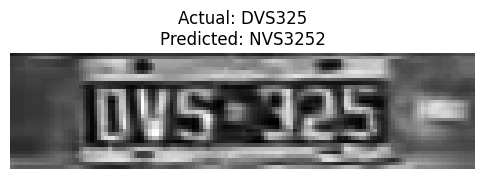

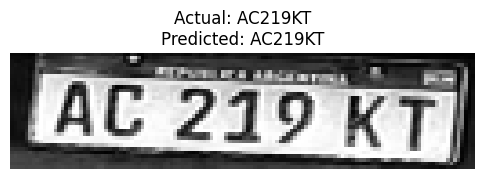

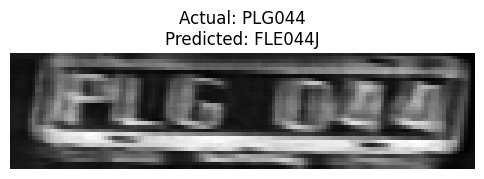

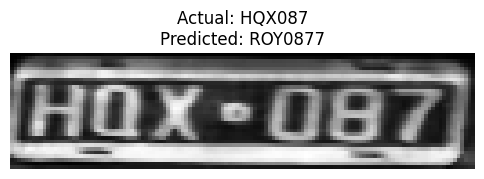

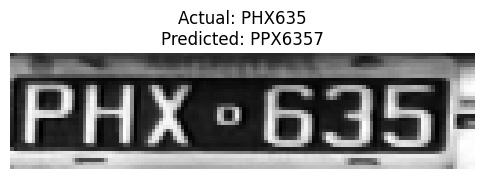

In [131]:
def show_sample_prediction(sample_img, predicted_text, actual_text=None):
    plt.figure(figsize=(6, 2))
    
    # Show the grayscale image
    plt.imshow(sample_img, cmap="gray")
    plt.axis("off")  # Hide axis
    
    # Format the title
    if actual_text:
        plt.title(f"Actual: {actual_text}\nPredicted: {predicted_text}", fontsize=12)
    else:
        plt.title(f"Predicted: {predicted_text}", fontsize=12)
    
    # Show the plot
    plt.show()
    
for i in range(5):
    show_sample_prediction(X_test[i].squeeze(), decoded_texts2[i], test_labels[i])

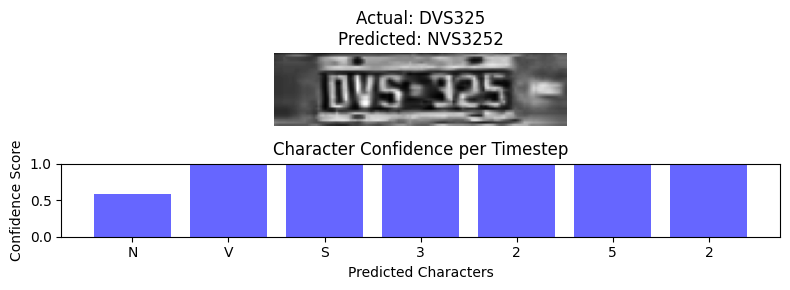

In [132]:
def show_sample_prediction_with_confidence(sample_img, prediction_probs, predicted_text, actual_text=None):
    plt.figure(figsize=(8, 3))

    # Show the grayscale image
    plt.subplot(2, 1, 1)  # First subplot: License plate image
    plt.imshow(sample_img, cmap="gray")
    plt.axis("off")
    
    # Format title
    title_text = f"Predicted: {predicted_text}"
    if actual_text:
        title_text = f"Actual: {actual_text}\n{title_text}"
    plt.title(title_text, fontsize=12)

    # Compute confidence scores
    pred_indices = np.argmax(prediction_probs, axis=-1)  # Get predicted indices
    confidence_scores = prediction_probs[np.arange(len(pred_indices)), pred_indices]  # Extract corresponding confidences

    # Trim confidence scores to match length of the predicted text
    confidence_scores = confidence_scores[:len(predicted_text)]

    # Plot confidence scores
    plt.subplot(2, 1, 2)  # Second subplot: Confidence scores
    plt.bar(range(len(predicted_text)), confidence_scores, tick_label=list(predicted_text), color="blue", alpha=0.6)
    plt.ylim(0, 1)  # Confidence between 0 and 1
    plt.xlabel("Predicted Characters")
    plt.ylabel("Confidence Score")
    plt.title("Character Confidence per Timestep")

    # Show plot
    plt.tight_layout()
    plt.show()

# Example usage with one test image
sample_index = 0  # Change index to visualize different images
show_sample_prediction_with_confidence(
    X_test[sample_index].squeeze(), 
    predictions2[sample_index], 
    decoded_texts2[sample_index], 
    test_labels[sample_index]
)

In [133]:
def ctc_fixed_length_decoder(predictions, blank_index=NUM_CLASSES - 1, max_length=6):
    decoded_texts = []
    for pred in predictions:
        pred_indices = np.argmax(pred, axis=-1)  # Get most probable class index at each timestep
        
        # Convert indices to characters (KEEPING DUPLICATES)
        pred_text = ''.join([index_to_char[idx] for idx in pred_indices if idx != blank_index])
        
        # **Truncate to First 7 Characters**
        pred_text = pred_text[:max_length]
        
        decoded_texts.append(pred_text)
    
    return decoded_texts


In [139]:
decoded_texts2 = ctc_fixed_length_decoder(predictions2)

# Show sample predictions
for i in range(5):
    print(f"Actual: {test_labels[i]} -> Predicted: {decoded_texts2[i]}")


Actual: DVS325 -> Predicted: NVS325
Actual: AC219KT -> Predicted: AC219K
Actual: PLG044 -> Predicted: FLE044
Actual: HQX087 -> Predicted: ROY087
Actual: PHX635 -> Predicted: PPX635


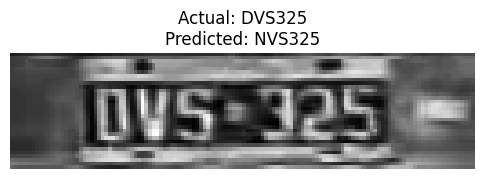

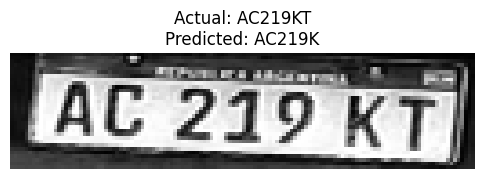

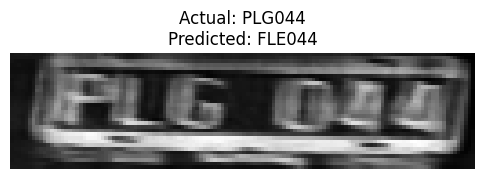

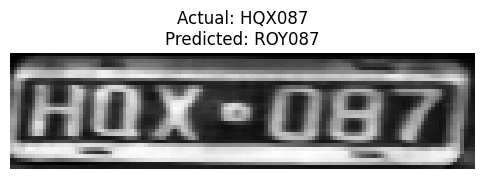

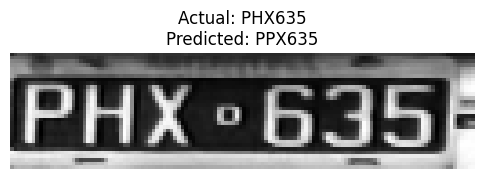

In [140]:
# Example usage with one test image
for i in range(5):
    show_sample_prediction(X_test[i].squeeze(), decoded_texts2[i], test_labels[i])


##### Evaluate the model

In [145]:
from jiwer import wer, cer

def calculate_metrics(actual_texts, predicted_texts):
    """
    Computes the accuracy and character error rate (CER) between actual and predicted license plates.
    """
    total_samples = len(actual_texts)
    correct_predictions = sum(1 for a, p in zip(actual_texts, predicted_texts) if a == p)

    # Accuracy Calculation
    accuracy = correct_predictions / total_samples * 100  # Percentage

    # Compute CER (Character Error Rate)
    cer_score = np.mean([cer(a, p) for a, p in zip(actual_texts, predicted_texts)])

    return accuracy, cer_score

# Example Usage:
accuracy, cer_score = calculate_metrics(test_labels, decoded_texts2)
print(f"🔹 CRNN Accuracy: {accuracy:.2f}%")
print(f"🔹 CRNN Character Error Rate (CER): {cer_score:.4f}")


🔹 CRNN Accuracy: 15.33%
🔹 CRNN Character Error Rate (CER): 0.2800
